# Task 3: Drug Repurposing

This notebook demonstrates **Task 3** of the scGVP downstream analysis pipeline: identifying novel therapeutic applications for existing drugs by comparing their perturbation signatures in the model's latent space.

## Rationale
If two drugs produce similar transcriptomic perturbation patterns, they may share mechanism-of-action targets and could be effective against the same diseases. scGVP encodes each drug's perturbation effect as a latent-space delta vector; cosine similarity across all drug pairs reveals structural clusters that can guide repurposing hypotheses.

## Workflow
1. Load the pre-trained GINVAE model and LINCS dataset
2. Process the reference dataset
3. Extract per-drug perturbation signatures
4. Compute cosine similarity matrix
5. Find the most similar drugs for a query set
6. Predict repurposing candidates for known disease drugs
7. Visualise the drug perturbation space with UMAP

## Outputs
- `smiles_to_name_mapping.csv` — SMILES → molecular formula mapping
- `drug_metadata.csv` — drug cell-type and sample-count metadata
- `drug_similarity_matrix.csv` — full pairwise cosine similarity matrix
- `drug_repurposing_candidates.csv` — ranked repurposing candidates
- `drug_repurposing_detailed.csv` — per-reference-drug detailed similarities
- `drug_space_umap.pdf` — UMAP plot of drug perturbation space
- `drug_space_umap_coordinates.csv` — 2D UMAP coordinates with metadata

## 1. Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

from model import GINVAE
from dataset import ChunkedGeneGraphDataset
from task3 import DrugRepurposing

print(f"PyTorch: {torch.__version__}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.9.0.dev20250827+cu129
Device : cuda


## 2. Configuration

Datasets and model weights are available at:  
**https://huggingface.co/datasets/Mike2481/Dataset4scGVP/tree/main**

In [2]:
MODEL_PATH  = '../src/best_gin_vae_model_node_level.pth'
LINCS_PATH  = '../lincs/merged_all_965_with_morgan.h5ad'
TAHOE_PATHS = [f'../minitahoe/p{i}_with_morgan.h5ad' for i in range(1, 15)]
REF_CACHE   = './output/reference_latents.pkl'
SAVE_DIR    = './output/task2_drug_network'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('./output', exist_ok=True)

# Maximum number of drugs to process (reduce for quick testing)
MAX_DRUGS = 50

## 3. Load Model

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GINVAE(input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Model loaded on {device}")

Model loaded on cuda


## 4. Load Data

In [4]:
lincs_adata = sc.read_h5ad(LINCS_PATH)
print(f"LINCS dataset: {lincs_adata.shape[0]} cells × {lincs_adata.shape[1]} genes")
print(f"Unique drugs : {lincs_adata.obs['canonical_smiles'].nunique()}")

lincs_dataset = ChunkedGeneGraphDataset([LINCS_PATH], split='test')
print(f"Dataset samples: {len(lincs_dataset)}")

LINCS dataset: 157138 cells × 965 genes
Unique drugs : 8316
Found 32 chunks with 157138 total samples
Dataset samples: 157138


## 5. Process Reference Dataset

In [5]:
model.process_reference_dataset(
    x_ref_dataset=lincs_dataset,
    save_path=REF_CACHE,
    force_reprocess=False
)
print("Reference dataset ready.")

Loading existing processed data from ./output/reference_latents.pkl
Loaded reference data metadata from ./output/reference_latents.pkl
Total samples available: 157138
Loading data from chunks...


Loading chunks: 100%|██████████| 16/16 [00:02<00:00,  6.31it/s, file=chunk_15.pkl]


Loaded and filtered 157138 samples from chunks
Computing biological context from 78569 control and 78569 perturb samples
Extracting graph-level latent representations...


Processing perturb samples: 100%|██████████| 78569/78569 [00:01<00:00, 49069.78it/s]


Computing mean representations...
References computed successfully.
Control ref shape: torch.Size([1, 100]), norm: 3.5154
perturb ref shape: torch.Size([1, 100]), norm: 3.5215
Biological context norm: 0.0068
Reference dataset ready.


## 6. Initialise DrugRepurposing

In [6]:
task3 = DrugRepurposing(model, device, output_dir=SAVE_DIR)
print("DrugRepurposing initialised.")

Output directory: ./output/task2_drug_network
DrugRepurposing initialised.


## 7. Extract Drug Perturbation Signatures

For each drug, the model predicts the perturbation response on several control samples and averages the predicted delta (perturbed − control expression) to form a signature vector.

In [7]:
drug_signatures, drug_metadata = task3.extract_drug_signatures(
    adata=lincs_adata,
    test_dataset=lincs_dataset,
    max_drugs=MAX_DRUGS,
    convert_smiles=True   # Convert SMILES to molecular formula names
)

print(f"\nExtracted signatures for {len(drug_signatures)} drugs")
print(f"Signature dimension: {next(iter(drug_signatures.values())).shape}")

Extracting drug perturbation signatures...
Converting SMILES to drug names...


Processing SMILES: 100%|██████████| 50/50 [00:00<00:00, 6971.45it/s]


SMILES to name mapping saved to ./output/task2_drug_network/smiles_to_name_mapping.csv


Processing drugs: 100%|██████████| 50/50 [00:12<00:00,  4.05it/s]

Extracted signatures for 50 drugs
Drug metadata saved to ./output/task2_drug_network/drug_metadata.csv

Extracted signatures for 50 drugs
Signature dimension: (965,)


In [8]:
# Preview drug metadata
meta_df = pd.DataFrame.from_dict(drug_metadata, orient='index')
print("Drug metadata sample:")
display(meta_df.head(10))

Drug metadata sample:


,drug_name,cell_type,smiles,n_samples
BrCC(=O)NCCc1ccc2ccccc2c1,C14H14BrNO_MW292.2,NPC,BrCC(=O)NCCc1ccc2ccccc2c1,1
Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53,C19H16BrNO2_MW370.2,A375,Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53,4
Brc1ccc(Cn2cncc2Cn2cc(C(=O)N3CCOCC3)c(c2)-c2cccc3ccccc23)cc1,C30H27BrN4O2_MW555.5,22RV1,Brc1ccc(Cn2cncc2Cn2cc(C(=O)N3CCOCC3)c(c2)-c2cc...,29
Brc1ccc(cc1)-c1csc(n1)N1CCNCC1,C13H14BrN3S_MW324.2,MCF7,Brc1ccc(cc1)-c1csc(n1)N1CCNCC1,3
Brc1cccc(Nc2ncnc3ccc(NC(=O)C=C)cc23)c1,C17H13BrN4O_MW369.2,A375,Brc1cccc(Nc2ncnc3ccc(NC(=O)C=C)cc23)c1,10
Brc1ccccc1CNC(=O)c1cccs1,C12H10BrNOS_MW296.2,A375,Brc1ccccc1CNC(=O)c1cccs1,7
Brc1ccccc1OCC(=O)NCCc2nc3ccccc3[nH]2,C17H16BrN3O2_MW374.2,A375,Brc1ccccc1OCC(=O)NCCc2nc3ccccc3[nH]2,7
C(C=Cc1ccccc1)N1CCN(CC1)C(c1ccccc1)c1ccccc1,C26H28N2_MW368.5,MCF7,C(C=Cc1ccccc1)N1CCN(CC1)C(c1ccccc1)c1ccccc1,2
C(CN1CCOCC1)Sc2nc3ccccc3n2Cc4ccccc4,C20H23N3OS_MW353.5,A549,C(CN1CCOCC1)Sc2nc3ccccc3n2Cc4ccccc4,7
C(N(Cc1ccccc1)Cc2ccccc2)c3nnc(s3)c4cc5ccccc5[nH]4,C25H22N4S_MW410.5,MCF7,C(N(Cc1ccccc1)Cc2ccccc2)c3nnc(s3)c4cc5ccccc5[nH]4,3


## 8. Compute Drug–Drug Similarity Matrix

Signatures are standardised and compared with cosine similarity.

In [9]:
similarity_df = task3.compute_drug_similarity(drug_signatures, save_to_csv=True)

print(f"Similarity matrix shape: {similarity_df.shape}")
print(f"Similarity range: [{similarity_df.values[~np.eye(len(similarity_df), dtype=bool)].min():.3f},"
      f" {similarity_df.values[~np.eye(len(similarity_df), dtype=bool)].max():.3f}]")

Computing drug-drug similarity...
Drug similarity matrix saved to ./output/task2_drug_network/drug_similarity_matrix.csv
Similarity matrix shape: (50, 50)
Similarity range: [-0.532, 0.988]


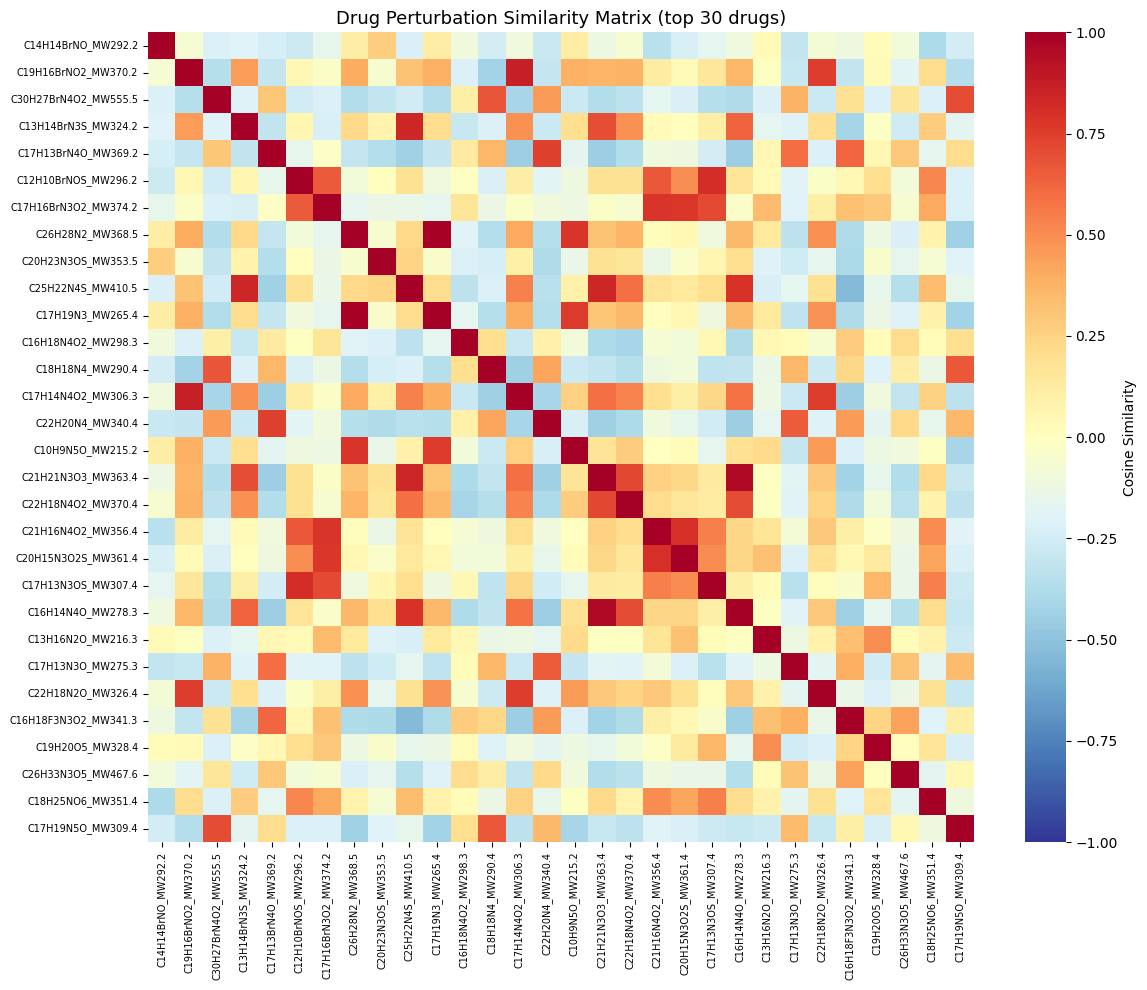

In [10]:
# Visualise a heatmap of the similarity matrix (first 30 drugs)
n_show = min(30, len(similarity_df))
sub_sim = similarity_df.iloc[:n_show, :n_show]

# Use drug names as labels
drugs_list = list(similarity_df.index[:n_show])
labels = [drug_metadata.get(d, {}).get('drug_name', d[:15]) for d in drugs_list]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    sub_sim.values,
    xticklabels=labels, yticklabels=labels,
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, cbar_kws={'label': 'Cosine Similarity'}
)
ax.set_title(f'Drug Perturbation Similarity Matrix (top {n_show} drugs)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'similarity_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Find Most Similar Drugs for a Query Drug

In [11]:
# Select the first drug as a query
query_drug = list(drug_signatures.keys())[0]
query_name = drug_metadata.get(query_drug, {}).get('drug_name', query_drug[:30])
print(f"Query drug: {query_name}")

similar_drugs = task3.find_similar_drugs(
    target_drug=query_drug,
    similarity_df=similarity_df,
    drug_metadata=drug_metadata,
    top_k=10,
    save_to_csv=True
)

print(f"\nTop 10 drugs similar to {query_name[:40]}:")
similar_names = [(drug_metadata.get(d, {}).get('drug_name', d[:25]), f"{s:.4f}")
                 for d, s in similar_drugs.items()]
for name, score in similar_names:
    print(f"  {name:40s}  similarity={score}")

Query drug: C14H14BrNO_MW292.2
Similar drugs for C14H14BrNO_MW292.2 saved to ./output/task2_drug_network/similar_drugs_C14H14BrNO_MW292.2.csv

Top 10 drugs similar to C14H14BrNO_MW292.2:
  C9H11N_MW133.2                            similarity=0.8831
  C17H28O2S_MW296.5                         similarity=0.4253
  C26H33NO2_MW391.6                         similarity=0.3802
  C31H32N6O2_MW520.6                        similarity=0.3047
  C20H23N3OS_MW353.5                        similarity=0.2724
  C30H48O3_MW456.7                          similarity=0.1223
  C26H28N2_MW368.5                          similarity=0.1165
  C10H9N5O_MW215.2                          similarity=0.1151
  C17H19N3_MW265.4                          similarity=0.1118
  C10H14N2_MW162.2                          similarity=0.0839


## 10. Predict Repurposing Candidates

Given a set of drugs known to treat a disease, find all other drugs above the similarity threshold — these are repurposing candidates.

In [12]:
# Treat the first 5 drugs as "known disease drugs"
known_disease_drugs = list(drug_signatures.keys())[:5]
known_names = [drug_metadata.get(d, {}).get('drug_name', d[:20]) for d in known_disease_drugs]
print("Known disease drugs:")
for n in known_names:
    print(f"  {n}")

repurposing_candidates = task3.predict_repurposing_candidates(
    disease_drugs=known_disease_drugs,
    all_drugs_signatures=drug_signatures,
    drug_metadata=drug_metadata,
    similarity_threshold=0.7
)

print(f"\nFound {len(repurposing_candidates)} repurposing candidates")
if len(repurposing_candidates) > 0:
    print("\nTop 10 repurposing candidates:")
    display(repurposing_candidates[['candidate_drug_name', 'n_similar_drugs', 'avg_similarity', 'max_similarity']].head(10))

Known disease drugs:
  C14H14BrNO_MW292.2
  C19H16BrNO2_MW370.2
  C30H27BrN4O2_MW555.5
  C13H14BrN3S_MW324.2
  C17H13BrN4O_MW369.2
Predicting repurposing candidates for 5 known drugs...
Computing drug-drug similarity...
Drug similarity matrix saved to ./output/task2_drug_network/drug_similarity_matrix.csv
Drug repurposing candidates saved to ./output/task2_drug_network/drug_repurposing_candidates.csv
Detailed repurposing results saved to ./output/task2_drug_network/drug_repurposing_detailed.csv

Found 7 repurposing candidates

Top 10 repurposing candidates:


,candidate_drug_name,n_similar_drugs,avg_similarity,max_similarity
0,C9H11N_MW133.2,1,0.883097,0.883097
1,C17H14N4O2_MW306.3,1,0.861979,0.861979
5,C25H22N4S_MW410.5,1,0.836055,0.836055
2,C22H18N2O_MW326.4,1,0.757062,0.757062
6,C22H20N4_MW340.4,1,0.744717,0.744717
3,C4H10N2_MW86.1,1,0.727811,0.727811
4,C17H19N5O_MW309.4,1,0.703574,0.703574


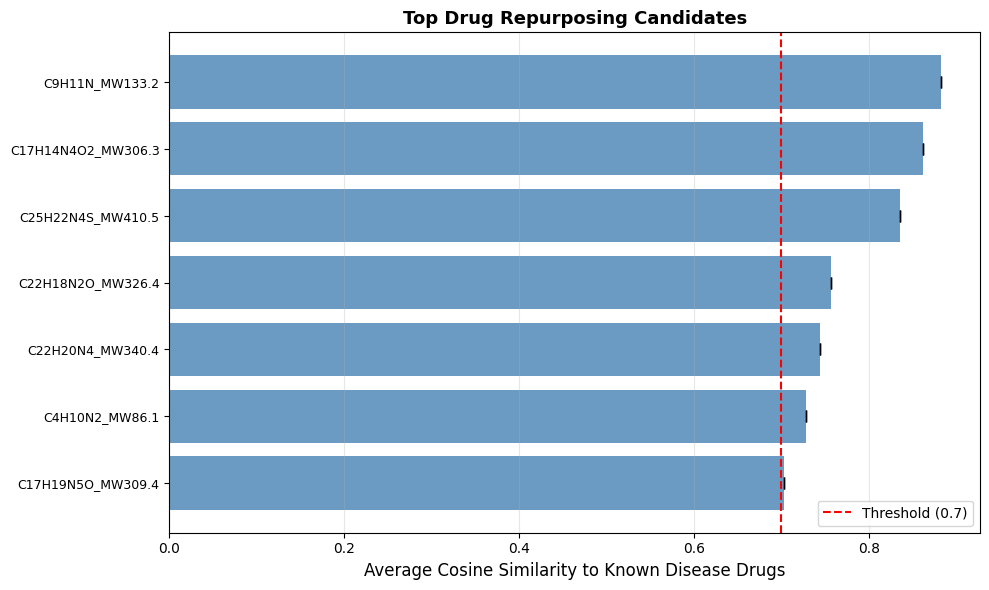

In [13]:
# Bar chart of top repurposing candidates
if len(repurposing_candidates) > 0:
    top_n = min(15, len(repurposing_candidates))
    top_cands = repurposing_candidates.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = np.arange(top_n)
    ax.barh(y_pos, top_cands['avg_similarity'], xerr=top_cands['avg_similarity'] - top_cands['min_similarity'],
            color='steelblue', alpha=0.8, capsize=4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([n[:40] for n in top_cands['candidate_drug_name']], fontsize=9)
    ax.set_xlabel('Average Cosine Similarity to Known Disease Drugs', fontsize=12)
    ax.set_title('Top Drug Repurposing Candidates', fontsize=13, fontweight='bold')
    ax.axvline(0.7, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.7)')
    ax.legend()
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'repurposing_candidates.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. UMAP Visualisation of Drug Perturbation Space

UMAP reduces the high-dimensional drug signatures to 2D for visualisation. Known disease drugs are highlighted with red stars.

In [14]:
umap_df = task3.visualize_drug_space(
    drug_signatures=drug_signatures,
    drug_metadata=drug_metadata,
    highlight_drugs=known_disease_drugs,
    save_path=os.path.join(SAVE_DIR, 'drug_space_umap.pdf')
)

print(f"UMAP coordinates saved. Shape: {umap_df.shape}")
display(umap_df.head(5))

Performing UMAP dimensionality reduction...
UMAP coordinates saved to ./output/task2_drug_network/drug_space_umap_coordinates.csv
Drug space visualization saved to ./output/task2_drug_network/drug_space_umap.pdf
UMAP coordinates saved. Shape: (50, 6)


,drug_id,drug_name,UMAP1,UMAP2,cell_type,smiles
0,BrCC(=O)NCCc1ccc2ccccc2c1,C14H14BrNO_MW292.2,6.568085,3.373411,NPC,BrCC(=O)NCCc1ccc2ccccc2c1
1,Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53,C19H16BrNO2_MW370.2,3.640175,5.381313,A375,Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53
2,Brc1ccc(Cn2cncc2Cn2cc(C(=O)N3CCOCC3)c(c2)-c2cc...,C30H27BrN4O2_MW555.5,4.330189,1.595315,22RV1,Brc1ccc(Cn2cncc2Cn2cc(C(=O)N3CCOCC3)c(c2)-c2cc...
3,Brc1ccc(cc1)-c1csc(n1)N1CCNCC1,C13H14BrN3S_MW324.2,3.255347,6.083710,MCF7,Brc1ccc(cc1)-c1csc(n1)N1CCNCC1
4,Brc1cccc(Nc2ncnc3ccc(NC(=O)C=C)cc23)c1,C17H13BrN4O_MW369.2,5.153720,2.084561,A375,Brc1cccc(Nc2ncnc3ccc(NC(=O)C=C)cc23)c1


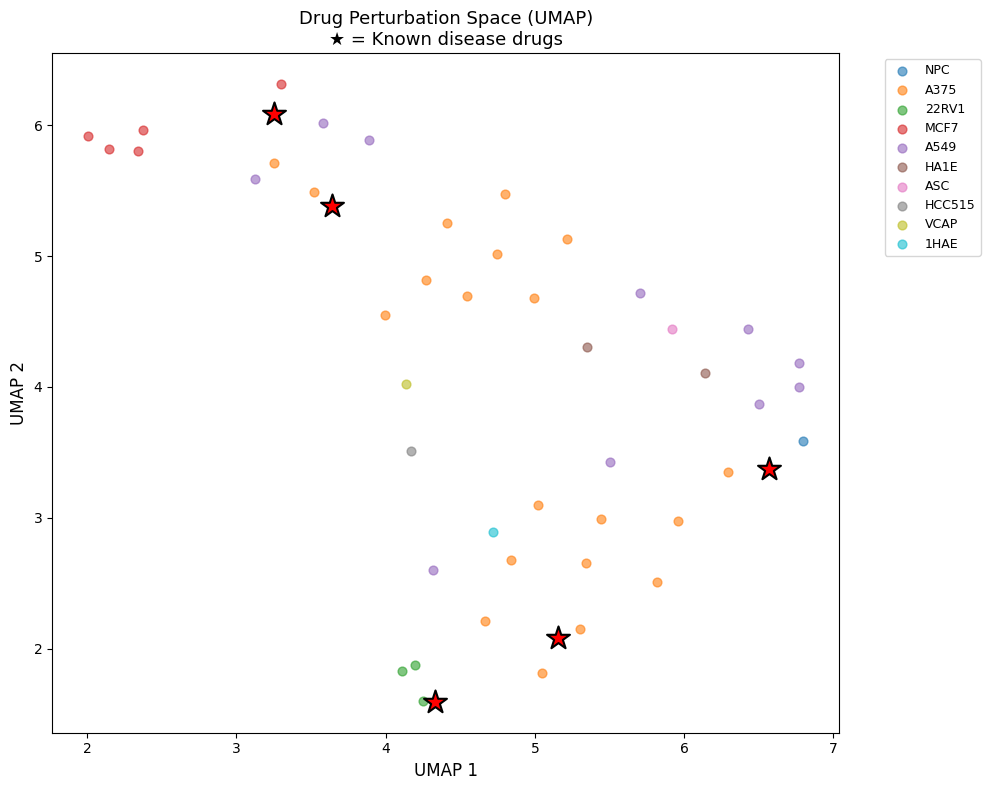

In [15]:
# Inline UMAP plot
if umap_df is not None and len(umap_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    cell_types = umap_df['cell_type'].unique()
    palette = plt.cm.tab10(np.linspace(0, 1, len(cell_types)))
    for ct, color in zip(cell_types, palette):
        mask = umap_df['cell_type'] == ct
        ax.scatter(umap_df.loc[mask, 'UMAP1'], umap_df.loc[mask, 'UMAP2'],
                   c=[color], label=ct, alpha=0.6, s=40)

    # Highlight known disease drugs
    for drug in known_disease_drugs:
        row = umap_df[umap_df['drug_id'] == drug]
        if len(row) > 0:
            ax.scatter(row['UMAP1'].values[0], row['UMAP2'].values[0],
                       c='red', s=300, marker='*', edgecolors='black', linewidths=1.5,
                       zorder=5)

    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title('Drug Perturbation Space (UMAP)\n★ = Known disease drugs', fontsize=13)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'drug_space_umap_inline.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 12. Summary

In [16]:
print("=" * 60)
print("Task 3: Drug Repurposing — Summary")
print("=" * 60)
print(f"  Drugs analysed          : {len(drug_signatures)}")
print(f"  Known disease drugs     : {len(known_disease_drugs)}")
print(f"  Repurposing candidates  : {len(repurposing_candidates)}")
if len(repurposing_candidates) > 0:
    best = repurposing_candidates.iloc[0]
    print(f"  Best candidate          : {best['candidate_drug_name'][:40]}")
    print(f"  Best avg similarity     : {best['avg_similarity']:.4f}")
print(f"\nAll outputs saved to: {SAVE_DIR}")

Task 3: Drug Repurposing — Summary
  Drugs analysed          : 50
  Known disease drugs     : 5
  Repurposing candidates  : 7
  Best candidate          : C9H11N_MW133.2
  Best avg similarity     : 0.8831

All outputs saved to: ./output/task2_drug_network
